In [ ]:
"""
LLM Inference Pipeline
----------------------
Input  : list of prompt strings
Output : list of completion strings

Model  : meta-llama/Llama-3.2-3B-Instruct (loaded locally via transformers)

Requirements:
    pip install transformers accelerate torch tqdm

Optional – set HF_TOKEN in env or .env to download gated models:
    export HF_TOKEN=hf_...
"""

import time
import random
from typing import List, Optional
from tqdm import tqdm

import torch
from transformers import pipeline
from dotenv import load_dotenv

load_dotenv()

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

#MODEL_REPO             = "meta-llama/Llama-3.2-3B" -Instruct
MODEL_REPO             = "google/gemma-3-270m" #-it
#HF_TOKEN               = os.environ.get("HF_TOKEN")   # needed for gated model
DEFAULT_MAX_NEW_TOKENS = 1024
DEFAULT_MAX_WORKERS    = 4    # keep low: threads share the same GPU/CPU
DEFAULT_BATCH_SIZE     = 16   # pipeline handles batching internally

# ---------------------------------------------------------------------------
# Load model once at import time
# ---------------------------------------------------------------------------

def _load_pipeline():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype  = torch.float16 if device == "cuda" else torch.float32
    pipe = pipeline(
        "text-generation",
        model=MODEL_REPO,
        #token=HF_TOKEN,
        #dtype=dtype,
        device_map="auto",   # spreads across all GPUs / falls back to CPU
    )
    return pipe

_pipe = _load_pipeline()

# ---------------------------------------------------------------------------
# Retry decorator
# ---------------------------------------------------------------------------

def retry_with_exponential_backoff(
    func,
    retries: int          = 5,
    initial_sleep: float  = 2.0,
    jitter: bool          = True,
    backoff_factor: float = 1.5,
):
    def wrapper(*args, **kwargs):
        sleep_time = initial_sleep
        for attempt in range(retries):
            try:
                return func(*args, **kwargs)
            except Exception as e:
                print(f"[Attempt {attempt + 1}/{retries}] Error: {e}")
                if attempt < retries - 1:
                    sleep_time *= backoff_factor * (1 + jitter * random.random())
                    print(f"  Retrying in {sleep_time:.1f}s ...")
                    time.sleep(sleep_time)
                else:
                    raise
        raise RuntimeError(f"Maximum retries ({retries}) exceeded")
    return wrapper

# ---------------------------------------------------------------------------
# Single-prompt completion
# ---------------------------------------------------------------------------

from datasets import Dataset
from transformers.pipelines.pt_utils import KeyDataset


def process_in_parallel(
    prompts: List[str],
    max_workers: int    = DEFAULT_MAX_WORKERS,
    batch_size: int     = DEFAULT_BATCH_SIZE,
    max_new_tokens: int = DEFAULT_MAX_NEW_TOKENS,
) -> List[Optional[str]]:
    """
    Process prompts efficiently using HuggingFace Dataset batching.
    """
    dataset = Dataset.from_dict({"prompt": prompts})

    results: List[Optional[str]] = [None] * len(prompts)

    outputs = _pipe(
        KeyDataset(dataset, "prompt"),
        max_new_tokens=max_new_tokens,
        return_full_text=False,
        do_sample=False,
        temperature=0,
        batch_size=batch_size,
    )

    for idx, output in enumerate(tqdm(outputs, total=len(prompts), desc="Generating")):
        try:
            generated = output[0]["generated_text"]
            if isinstance(generated, list):
                results[idx] = generated[-1].get("content", "")
            else:
                results[idx] = generated
        except Exception as e:
            print(f"[ERROR] prompt index {idx}: {e}")

    return results

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from sonar.inference_pipelines.text import TextToEmbeddingModelPipeline
t2vec_model = TextToEmbeddingModelPipeline(encoder="text_sonar_basic_encoder", tokenizer="text_sonar_basic_encoder", device=device)

import pickle

def split_data(results):
    split_dataset = []
    for i, completion in enumerate(results):
        completion_parts = completion.split("\n\n")
        completions = [x+"\n\n" for x in completion_parts[:-1]]
        if completion_parts:
            completions.append(completion_parts[-1])

        split_dataset.append(completions)
    return split_dataset

def save(split_dataset, n_prompts, genre):
    filehandler = open('save_completions/gemma_data/' + str(n_prompts) + '_' + genre+'.pkl', 'wb')
    pickle.dump(split_dataset, filehandler)

def embed(split_dataset, n):
    embeddings = []
    for text in tqdm(split_dataset): #we truncate at 20, we already have n, so we cut at 20-n
        embeddings.append(t2vec_model.predict(text[:20-n], source_lang="eng_Latn"))
    return embeddings

In [ ]:
# Use the instruct model here
prompt = [i[0] for i in torch.load('fineweb_random.pth')[-1000:]] #it's the test dataset 

results = process_in_parallel(prompt)

split_dataset = split_data(results)

save(split_dataset, 1, 'text')

embeddings = embed(split_dataset, 1)

save(embeddings, 1, '')

In [ ]:
# Don't use the instruct model here
test_dataset = torch.load('fineweb_random.pth')[-1000:]

for n in range(2,20): #it stop at 19
    
    prompt = [i[:n] for i in test_dataset]
    liste = [''.join(sublist) for sublist in prompt]

    results = process_in_parallel(liste)

    split_dataset = split_data(results)

    save(split_dataset, n, 'text')

    embeddings = embed(split_dataset, n)

    save(embeddings, n, '')

/tmp/ipykernel_1923942/556745999.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_dataset = torch.load('fineweb_random.pth')[-1000:]
Generating:   0%|          | 0/1

In [17]:
import torch, pickle
_, target_data = torch.load('../sentemb/data/test_sonarprompt_sonaroutput.pth')

from torch import nn
import torch.nn.functional as F
import numpy as np
cos = nn.CosineSimilarity(dim=-1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def calculate_score(output, targets, filler):

    score_one_sum = 0
    score_sum_pad = torch.zeros(filler).to(device)
    pad_nbr_sum = torch.zeros(filler).to(device)

    for batch, target in enumerate(targets):
        out = output[batch].to(device)

        score = cos(out, target)

        score_one_sum += score.mean()
        score_sum_pad += F.pad(score, (0, filler - len(score)))
        pad_nbr_sum += F.pad(torch.ones(len(score)), (0, filler - len(score))).to(device)

    paragraphed_score = score_sum_pad/pad_nbr_sum
    paragraphed_score = [round(elem.item(), 2) for elem in paragraphed_score]
    final_score = score_one_sum.item()/len(targets)
    return final_score, paragraphed_score

/tmp/ipykernel_2073633/1268498760.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _, target_data = torch.load('../sentemb/data/test_sonarprompt_sonaroutput.pth')


In [ ]:
import pandas as pd
import numpy as np

# ====================== DATA COLLECTION ======================
data = []
list_final_score = []   # to calculate the overall average
seq = 19

for n_parag in range(seq):
    with open("save_completions/gemma_data/"+str(n_parag+1)+".pkl", "rb") as f:
    #with open("save_completions/llama_data/"+str(n_parag+1)+".pkl", "rb") as f:
        control_data = pickle.load(f)

    filler=seq-n_parag

    target = [tensor[n_parag:] for tensor in target_data]
    control = control_data

    target = [a[:min(len(a), len(b))] for a, b in zip(target, control)]
    control = [b[:min(len(a), len(b))] for a, b in zip(target, control)]

    target = [t for t in target if t.numel() > 0]
    control = [t for t in control if t.numel() > 0]

    final_score, raw_scores = calculate_score(control, target, filler)
    
    list_final_score.append(final_score)
    
    avg_score = round(final_score, 3)
    scores_rounded = [round(s, 3) for s in raw_scores]
    
    if n_parag == 0:
        paragraph_label = "0 (the prompt)"
    else:
        paragraph_label = f"0:{n_parag}"
    
    data.append({
        'Paragraphs input': paragraph_label,
        'Average predictions for the following paragraphs': avg_score,
        'scores': scores_rounded
    })

# Calculating the overall average 
average = round(np.average(list_final_score), 3)

# ====================== DATAFRAME CREATION ======================
df = pd.DataFrame(data)

# Creating columns with the correct names: 1st, 2nd, 3rd, 4th, ...
max_len = max(len(row['scores']) for row in data)
col_names = []
for i in range(1, max_len + 1):
    if i == 1:
        suffix = "st"
    elif i == 2:
        suffix = "nd"
    elif i == 3:
        suffix = "rd"
    else:
        suffix = "th"
    col_names.append(f"{i}{suffix}")

for col in col_names:
    df[col] = None

# Offset filling (gaps on the left)
for row_idx, row in df.iterrows():
    n = row_idx  # n_parag
    scores = row['scores']
    for j, value in enumerate(scores):
        col_idx = n + j
        if col_idx < len(col_names):
            col_name = col_names[col_idx]
            df.at[row_idx, col_name] = value

# Deleting the temporary column
df = df.drop(columns=['scores'])

# ====================== ADDING THE AVERAGE ROW ======================
average_row = pd.DataFrame([{
    'Paragraphs input': 'Average:',
    'Average predictions for the following paragraphs': average,
} | {col: None for col in col_names}])

df = pd.concat([df, average_row], ignore_index=True)

# ====================== FINAL DISPLAY ======================
print(df.to_string(index=False, na_rep=''))

df.to_csv("gemma.csv", index=False)

Paragraphs input  Average predictions for the following paragraphs   1st   2nd   3rd   4th   5th   6th   7th   8th   9th  10th  11th  12th  13th  14th  15th  16th  17th  18th  19th
  0 (the prompt)                                             0.381  0.69  0.42  0.38  0.33  0.28  0.29  0.26  0.28  0.29  0.26  0.27  0.29  0.26  0.27  0.28  0.25  0.27  0.25  0.28
             0:1                                             0.116  None -0.03  0.15  0.18  0.16  0.17  0.18  0.17  0.17  0.18  0.18  0.17  0.18  0.18  0.16  0.18  0.15  0.16  0.16
             0:2                                             0.212  None  None  0.23  0.23  0.23  0.24  0.23  0.22  0.23  0.22  0.22  0.23  0.22  0.21  0.21  0.22   0.2  0.17   0.2
             0:3                                             0.257  None  None  None  0.29  0.24  0.26  0.24  0.24  0.21  0.23  0.22  0.21  0.21  0.21  0.18  0.22  0.19  0.18  0.21
             0:4                                             0.251  None  None  None  None  0.2

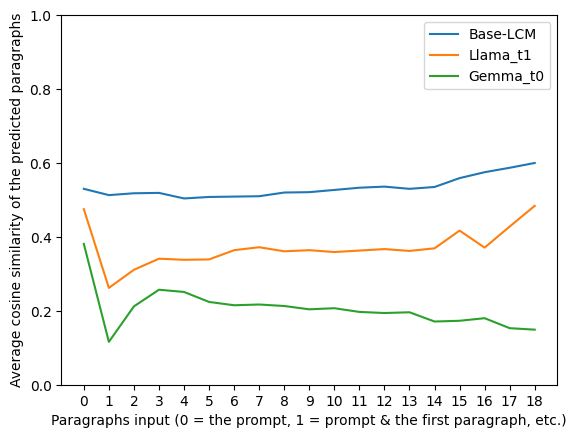

In [ ]:
import matplotlib.pyplot as plt

x = list(range(19))
GemmaT0 = [0.381,0.116,0.212,0.257,0.251,0.224,0.215,0.217,0.213,0.204,0.207,0.197,0.194,0.196,0.171,0.173,0.18,0.153,0.149]
BaseLCM = [0.53,0.513,0.518,0.519,0.504,0.508,0.509,0.51,0.52,0.521,0.527,0.533,0.536,0.53,0.535,0.559,0.575,0.587,0.6]
llamaT1 = [0.475,0.262,0.311,0.341,0.338,0.339,0.364,0.372,0.361,0.364,0.359,0.363,0.367,0.362,0.369,0.417,0.371,0.428,0.484]


plt.figure()
plt.plot(x, BaseLCM, label="Base-LCM")
plt.plot(x, llamaT1, label="Llama_t1")
plt.plot(x, GemmaT0, label="Gemma_t0")

plt.xlabel("Paragraphs input (0 = the prompt, 1 = prompt & the first paragraph, etc.)")
plt.ylabel("Average cosine similarity of the predicted paragraphs")

plt.ylim(0, 1)
plt.legend()
plt.xticks(x)

plt.show()